# Population genomics: a variant-calling cohort

A cohort study is a fan-in: many samples are processed independently down
identical paths, then joined into one cohort analysis. The awkward part is
never the compute. It is answering, three months later, which reference build
sample 7 was aligned against, why sample 3 is missing from the cohort, and
whether the association test you are about to publish used the filtered
calls or the raw ones.

This notebook builds that pipeline against synthetic data:

```
reference ---> sequence (x8) ---> qc ---> align ---> call ---\
                                                              +--> cohort --> association
```

Along the way it shows rules that refuse an invalid step, a sample that fails
QC and is kept as evidence rather than lost, a multi-parent join, and the
queries that answer the three-months-later questions.

## 1. Setup

In [1]:
import shutil
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ancestree
from ancestree.errors import InvalidTransition

# The store lives in a temp folder so the executed notebook leaves nothing
# behind. Point it at a real directory in your own work.
WORKDIR = Path(tempfile.mkdtemp(prefix="ancestree-genomics-"))
rng = np.random.default_rng(20260725)

BASES = np.array(list("ACGT"))
GENOME_LENGTH = 120_000
N_SAMPLES = 8
READ_COUNT = 4_000
READ_LENGTH = 150

## 2. Rules: the pipeline as a grammar

The ruleset names every step type and what it is allowed to follow.
`[None]` marks a valid starting point. Declaring this up front turns an
ordering mistake into an exception at the moment it happens, rather than a
plausible-looking result you trust for a week.

`gen_triggers` names the steps that begin a new generation. Here a fresh
`reference` opens one, so a rebuild of the reference cleanly separates
everything derived from it from everything derived from the old one.

In [2]:
RULES = {
    "reference": [None],
    "sequence": ["reference"],
    "qc": ["sequence"],
    "align": ["qc"],
    "call": ["align"],
    "cohort": ["call"],
    "association": ["cohort"],
}

store = ancestree.LineageStore(
    WORKDIR / "cohort_2026",
    rules=RULES,
    gen_triggers=["reference"],
)
store.rules

{'reference': [None],
 'sequence': ['reference'],
 'qc': ['sequence'],
 'align': ['qc'],
 'call': ['align'],
 'cohort': ['call'],
 'association': ['cohort']}

## 3. The reference build

One node, one artifact, and the facts that every downstream result will
inherit. Metadata is grouped so the explorer lays it out sensibly, and the
checksum is stored as display-only: worth recording, not worth searching.

In [3]:
reference = rng.choice(BASES, size=GENOME_LENGTH)

with store.create_node(step_type="reference") as node:
    np.save(node / "GRCsynth38.npy", reference)

    node.add_meta("build", "GRCsynth38", group="Reference")
    node.add_meta("length_bp", GENOME_LENGTH, group="Reference")
    node.add_meta(
        "gc_content",
        round(float(np.isin(reference, ["G", "C"]).mean()), 4),
        group="Reference",
    )
    node.add_meta(
        "source", "https://example.org/synthetic-reference", group="Reference"
    )
    node.add_meta(
        "md5", "b1946ac92492d2347c6235b4d2611184", group="Reference", searchable=False
    )

reference_node = node.node_id
print(
    f"reference node {reference_node}  generation {store.get(reference_node).generation}"
)

reference node b7a905de  generation 0


Read `node.node_id` *after* the block, not inside it. The handle is rebound
on exit, and with deduplication on, a node whose content already exists
collapses onto the existing one. An id copied out mid-block can name a node
that was never persisted.

## 4. Rules refuse an invalid step

Before going further, the grammar is worth testing. Alignment cannot follow
the reference directly: reads have to exist and pass QC first.

In [4]:
try:
    with store.create_node(step_type="align", parent=reference_node) as bad:
        bad.add_meta("note", "this never commits")
except InvalidTransition as exc:
    print(f"InvalidTransition: {exc}")

print(f"\nNodes in the store: {store.stats()['nodes']}  (the bad node never existed)")

InvalidTransition: Invalid transition: reference -> align. Allowed parents: ['qc'].

Nodes in the store: 1  (the bad node never existed)


## 5. Sequencing: eight samples off one reference

Each sample simulates reads drawn from the reference with a per-sample error
rate and a handful of true variants. Every sample is a child of the reference
node, so the fan-out is recorded rather than implied by a filename
convention.

Two of the eight are deliberately poor: sample 3 is degraded and sample 6 is
borderline.

In [5]:
DEGRADED = {3: 0.045, 6: 0.012}
TRUE_VARIANTS = sorted(rng.choice(GENOME_LENGTH, size=40, replace=False).tolist())


def simulate_reads(error_rate, variant_fraction):
    """Reads sampled from the reference, with sequencing error and a subset of
    the cohort's true variants spiked in."""
    genome = reference.copy()
    carried = [p for p in TRUE_VARIANTS if rng.random() < variant_fraction]
    for pos in carried:
        genome[pos] = rng.choice(BASES[BASES != genome[pos]])

    starts = rng.integers(0, GENOME_LENGTH - READ_LENGTH, size=READ_COUNT)
    reads = np.stack([genome[s : s + READ_LENGTH] for s in starts])
    errors = rng.random(reads.shape) < error_rate
    reads[errors] = rng.choice(BASES, size=int(errors.sum()))
    # Quality varies per read (library prep, cluster density) as well as per
    # base, so a degraded sample loses most reads rather than all of them.
    per_read = rng.normal(0, 3.0, size=(READ_COUNT, 1))
    quality = np.clip(
        rng.normal(36 - 180 * error_rate, 2, size=reads.shape) + per_read, 2, 41
    )
    return reads, quality, starts, carried


sequence_nodes = {}
for sample in range(N_SAMPLES):
    error_rate = DEGRADED.get(sample, 0.004)
    reads, quality, starts, carried = simulate_reads(error_rate, 0.35)

    with store.create_node(step_type="sequence", parent=reference_node) as node:
        np.save(node / "reads.npy", reads)
        np.save(node / "quality.npy", quality.astype(np.float32))
        np.save(node / "start_positions.npy", starts)

        node.add_meta("sample_id", f"NA{7000 + sample}", group="Sample")
        node.add_meta("cohort_arm", "case" if sample % 2 else "control", group="Sample")
        node.add_meta("run_flowcell", f"FC{sample // 3}", group="Sample")
        node.add_meta("reads", READ_COUNT, group="Sequencing")
        node.add_meta("read_length", READ_LENGTH, group="Sequencing")
        node.add_meta(
            "mean_quality", round(float(quality.mean()), 2), group="Sequencing"
        )
        node.add_meta(
            "true_variants", len(carried), group="Sequencing", searchable=False
        )

    sequence_nodes[sample] = node.node_id

print(f"{len(sequence_nodes)} samples sequenced")
print(f"reference now has {len(store.children(reference_node))} children")

8 samples sequenced
reference now has 8 children


### What the shared reference bought

Every sample's reads are drawn from the same genome, so most of their bytes
already exist in the chunk pool. Ancestree splits artifacts at
content-defined boundaries and stores each distinct chunk once, across the
whole store.

In [6]:
stats = store.stats()
print(f"  logical artifact bytes  {stats['artifact_bytes'] / 1e6:8.2f} MB")
print(f"  stored in the pool      {stats['chunk_stored_bytes'] / 1e6:8.2f} MB")
print(f"  deduplication ratio     {stats['dedup_ratio']:8.2f}x")
print(f"  distinct chunks         {stats['chunks']:8d}")

  logical artifact bytes     39.14 MB
  stored in the pool         18.06 MB
  deduplication ratio         2.17x
  distinct chunks             1030


## 6. QC, and a sample that fails it

QC is where a real cohort loses members. The failure mode that matters is not
the exception, it is the exception that leaves nothing behind to explain
itself.

Ancestree keeps partial work. If the block raises, everything written so far
is committed and the node is flagged `healthy=False`, then the exception
re-raises. The failed sample stays in the lineage as evidence, findable, with
its metrics attached.

In [7]:
MIN_QUALITY = 30.0


class QCFailure(RuntimeError):
    """Raised when a sample is too degraded to carry forward."""


qc_nodes = {}
for sample, seq_id in sequence_nodes.items():
    sequenced = store.get(seq_id)
    quality = np.load(sequenced / "quality.npy")
    reads = np.load(sequenced / "reads.npy")
    starts = np.load(sequenced / "start_positions.npy")

    keep = quality.mean(axis=1) >= MIN_QUALITY
    mean_q = float(quality.mean())

    try:
        with store.create_node(step_type="qc", parent=seq_id) as node:
            np.save(node / "passing_reads.npy", reads[keep])
            np.save(node / "passing_starts.npy", starts[keep])
            node.add_meta("sample_id", f"NA{7000 + sample}", group="Sample")
            node.add_meta("reads_in", len(reads), group="QC")
            node.add_meta("reads_passing", int(keep.sum()), group="QC")
            node.add_meta("pass_fraction", round(float(keep.mean()), 4), group="QC")
            node.add_meta("mean_quality", round(mean_q, 2), group="QC")

            if keep.mean() < 0.5:
                raise QCFailure(
                    f"sample NA{7000 + sample}: only {keep.mean():.1%} of reads "
                    f"pass Q{MIN_QUALITY:.0f}"
                )
        qc_nodes[sample] = node.node_id
    except QCFailure as exc:
        print(f"  DROPPED  {exc}")

print(f"\n{len(qc_nodes)} of {N_SAMPLES} samples passed QC")

  DROPPED  sample NA7003: only 22.8% of reads pass Q30

7 of 8 samples passed QC


The dropped sample is not gone. It is a node, flagged unhealthy, holding the
reads it managed to write and the metrics that condemned it.

In [8]:
failed = store.find(step_type="qc", healthy=False)
for node in failed:
    print(
        f"  {node.node_id}  {node.metadata['sample_id']['value']}  "
        f"pass_fraction={node.metadata['pass_fraction']['value']}  "
        f"mean_quality={node.metadata['mean_quality']['value']}"
    )
    print(
        f"           artifacts written before the failure: "
        f"{[p.name for p in node.artifacts()]}"
    )

  d19abc99  NA7003  pass_fraction=0.2275  mean_quality=27.88
           artifacts written before the failure: ['passing_reads.npy', 'passing_starts.npy']


## 7. Alignment and variant calling

Two more steps per surviving sample. Nothing new about the API here, but note
hard-codes a path: `store.get(id) / "file"` resolves an artifact wherever the
store lives, and inside a block `store.from_parent(node, "file")` reaches
straight into the previous step's outputs without naming it. Move the store,
reopen it on another machine, and the same code finds the same bytes.

In [9]:
def align(reads, starts):
    """Fraction of each read matching the reference at its true position."""
    scores = np.empty(len(reads))
    for i, (read, start) in enumerate(zip(reads, starts)):
        scores[i] = (read == reference[start : start + READ_LENGTH]).mean()
    return scores


call_nodes = {}
for sample, qc_id in qc_nodes.items():
    passing = store.get(qc_id)
    reads = np.load(passing / "passing_reads.npy")
    starts = np.load(passing / "passing_starts.npy")

    scores = align(reads, starts)
    mapped = scores >= 0.9

    with store.create_node(step_type="align", parent=qc_id) as node:
        np.save(node / "alignment_scores.npy", scores.astype(np.float32))
        np.save(node / "mapped_reads.npy", reads[mapped])
        np.save(node / "mapped_starts.npy", starts[mapped])
        node.add_meta("sample_id", f"NA{7000 + sample}", group="Sample")
        node.add_meta("aligner", "synthetic-bwa 0.1", group="Alignment")
        node.add_meta("mapping_rate", round(float(mapped.mean()), 4), group="Alignment")
        node.add_meta(
            "mean_identity", round(float(scores.mean()), 4), group="Alignment"
        )
    align_id = node.node_id

    with store.create_node(step_type="call", parent=align_id) as node:
        # from_parent reaches straight into the previous step's outputs
        # without naming the node or knowing where the store lives.
        aligned = np.load(store.from_parent(node, "mapped_reads.npy")[0])
        aligned_starts = np.load(store.from_parent(node, "mapped_starts.npy")[0])

        # Pile the reads up and call a variant wherever the consensus
        # disagrees with the reference.
        depth = np.zeros(GENOME_LENGTH, dtype=np.int32)
        mismatch = np.zeros(GENOME_LENGTH, dtype=np.int32)
        for read, start in zip(aligned, aligned_starts):
            window = slice(start, start + READ_LENGTH)
            depth[window] += 1
            mismatch[window] += read != reference[window]

        allele_fraction = np.where(depth > 0, mismatch / np.maximum(depth, 1), 0.0)
        called = np.flatnonzero((depth >= 4) & (allele_fraction >= 0.5))

        np.save(node / "depth.npy", depth)
        np.save(node / "variant_positions.npy", called)
        node.add_meta("sample_id", f"NA{7000 + sample}", group="Sample")
        node.add_meta("cohort_arm", "case" if sample % 2 else "control", group="Sample")
        node.add_meta("variants_called", len(called), group="Calling")
        node.add_meta("mean_depth", round(float(depth.mean()), 2), group="Calling")
        node.add_meta(
            "callable_fraction", round(float((depth >= 4).mean()), 4), group="Calling"
        )
        node.add_meta(
            "caller_config",
            {"min_depth": 4, "min_allele_fraction": 0.5, "ploidy": 2},
            group="Calling",
            data_type="json",
        )

    call_nodes[sample] = node.node_id

print(f"{len(call_nodes)} samples called")
print(
    f"variants per sample: "
    f"{[store.get(n).metadata['variants_called']['value'] for n in call_nodes.values()]}"
)

7 samples called
variants per sample: [13, 12, 10, 9, 13, 20, 12]


## 8. The join

A cohort node takes every per-sample call set as a parent. `parent=` accepts
a list, and the resulting node records all of them, so the merge is a real
edge in the graph rather than a claim in a README.

In [10]:
call_ids = list(call_nodes.values())

matrix = np.zeros((len(call_ids), GENOME_LENGTH), dtype=np.int8)
sample_labels, arms = [], []
for row, call_id in enumerate(call_ids):
    record = store.get(call_id)
    positions = np.load(record / "variant_positions.npy")
    matrix[row, positions] = 1
    sample_labels.append(record.metadata["sample_id"]["value"])
    arms.append(record.metadata["cohort_arm"]["value"])

segregating = np.flatnonzero(matrix.sum(axis=0) > 0)
genotypes = pd.DataFrame(
    matrix[:, segregating], index=sample_labels, columns=segregating.astype(str)
)

with store.create_node(step_type="cohort", parent=call_ids) as node:
    genotypes.to_csv(node / "genotype_matrix.csv")
    np.save(node / "segregating_sites.npy", segregating)

    node.add_meta("samples", len(call_ids), group="Cohort")
    node.add_meta("segregating_sites", len(segregating), group="Cohort")
    node.add_meta("cases", arms.count("case"), group="Cohort")
    node.add_meta("controls", arms.count("control"), group="Cohort")
    node.add_meta("excluded_samples", N_SAMPLES - len(call_ids), group="Cohort")
    node.add_meta(
        "genotype_preview", genotypes.iloc[:, :8], group="Cohort", data_type="table"
    )

cohort_id = node.node_id
cohort = store.get(cohort_id)
print(f"cohort node {cohort_id}")
print(f"  parents:    {len(cohort.parent_id)}")
print(f"  generation: {cohort.generation}")

cohort node 49b2f6c6
  parents:    7
  generation: 0


## 9. Association test, with a figure

A `Path` passed to `add_meta` is recognised as an image by its suffix and
rendered inline in the explorer, so the plot travels with the node rather
than sitting in a directory someone has to be told about.

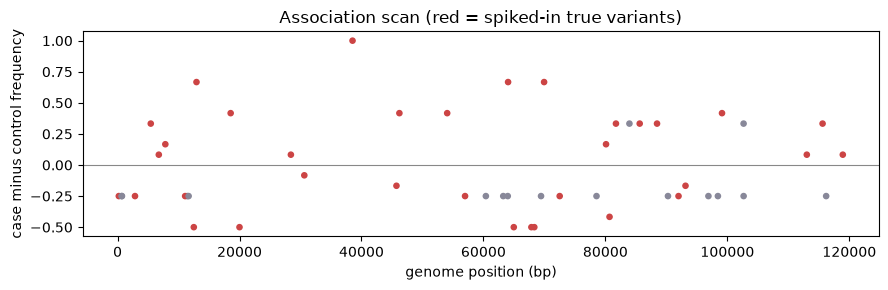

{'columns': ['position',
  'case_freq',
  'control_freq',
  'effect',
  'known_variant'],
 'rows': [[38533, 1.0, 0.0, 1.0, True],
  [12944, 0.667, 0.0, 0.667, True],
  [64042, 0.667, 0.0, 0.667, True],
  [69948, 0.667, 0.0, 0.667, True],
  [19997, 0.0, 0.5, -0.5, True],
  [12505, 0.0, 0.5, -0.5, True],
  [64978, 0.0, 0.5, -0.5, True],
  [67864, 0.0, 0.5, -0.5, True]]}

In [11]:
case_mask = np.array([a == "case" for a in arms])
case_freq = matrix[case_mask][:, segregating].mean(axis=0)
control_freq = matrix[~case_mask][:, segregating].mean(axis=0)
effect = case_freq - control_freq

results = pd.DataFrame(
    {
        "position": segregating,
        "case_freq": case_freq.round(3),
        "control_freq": control_freq.round(3),
        "effect": effect.round(3),
        "known_variant": np.isin(segregating, TRUE_VARIANTS),
    }
).sort_values("effect", key=abs, ascending=False)

with store.create_node(step_type="association", parent=cohort_id) as node:
    results.to_csv(node / "association_results.csv", index=False)

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.scatter(
        results["position"],
        results["effect"],
        c=np.where(results["known_variant"], "#c44", "#889"),
        s=14,
    )
    ax.axhline(0, color="#888", lw=0.8)
    ax.set_xlabel("genome position (bp)")
    ax.set_ylabel("case minus control frequency")
    ax.set_title("Association scan (red = spiked-in true variants)")
    fig.tight_layout()
    fig.savefig(node / "manhattan.png", dpi=110)
    plt.show()

    node.add_meta("test", "frequency difference", group="Association")
    node.add_meta("sites_tested", len(results), group="Association")
    node.add_meta(
        "top_effect", float(results["effect"].abs().max()), group="Association"
    )
    node.add_meta(
        "recovered_true_variants",
        int(results.head(20)["known_variant"].sum()),
        group="Association",
    )
    node.add_meta("top_hits", results.head(8), group="Association", data_type="table")
    node.add_meta(
        "scan", node / "manhattan.png", group="Association", data_type="image"
    )

association_id = node.node_id
store.get(association_id).metadata["top_hits"]["value"]

## 10. The three-months-later questions

The pipeline is done. These are the queries that make having recorded it
worth the trouble.

**Which reference did this result come from?** Walk the ancestry and filter
it in one call. `ancestors` is `find` restricted to a node's lineage.

In [12]:
ref = store.ancestors(association_id, step_type="reference")[0]
print(f"build      {ref.metadata['build']['value']}")
print(f"length_bp  {ref.metadata['length_bp']['value']}")
print(f"md5        {ref.metadata['md5']['value']}")

build      GRCsynth38
length_bp  120000
md5        b1946ac92492d2347c6235b4d2611184


**What was the full path from reference to result?** `lineage` returns every
ancestor plus the node itself, oldest first, each node after all of its
parents.

In [13]:
path = store.lineage(association_id)
print(f"{len(path)} nodes in the ancestry of {association_id}\n")
for record in path[:6]:
    label = record.metadata.get("sample_id", {}).get("value", "")
    print(
        f"  gen {record.generation}  {record.step_type:<12} {record.node_id}  {label}"
    )
print(f"  ... {len(path) - 8} more ...")
for record in path[-2:]:
    print(f"  gen {record.generation}  {record.step_type:<12} {record.node_id}")

31 nodes in the ancestry of 2b661aab

  gen 0  reference    b7a905de  
  gen 0  sequence     c34a9157  NA7007
  gen 0  qc           b4c05a44  NA7007
  gen 0  align        1d25ce7a  NA7007
  gen 0  call         4815c550  NA7007
  gen 0  sequence     00dac294  NA7006
  ... 23 more ...
  gen 0  cohort       49b2f6c6
  gen 0  association  2b661aab


**Why is sample NA7003 missing from the cohort?** Search by metadata value.
Structural attributes and searchable metadata share one namespace, so
`step_type` and `sample_id` filter the same way.

In [14]:
for record in store.find(sample_id="NA7003"):
    print(f"  {record.step_type:<10} {record.node_id}  healthy={record.healthy}")

dropped = store.find(sample_id="NA7003", healthy=False)[0]
print(f"\nDropped at: {dropped.step_type}")
print(
    f"Reason:     pass_fraction {dropped.metadata['pass_fraction']['value']} "
    f"below the 0.5 threshold"
)
print(f"Its reads:  {[p.name for p in dropped.artifacts()]}")

  sequence   e458b57e  healthy=True
  qc         d19abc99  healthy=False

Dropped at: qc
Reason:     pass_fraction 0.2275 below the 0.5 threshold
Its reads:  ['passing_reads.npy', 'passing_starts.npy']


**Which samples aligned badly enough to be worth rerunning?** Pass a callable
for a predicate. It receives the stored value, or `None` when the node has no
such key, which is why the guard matters: a bare `lambda r: r < 0.8` would
raise on every node that never aligned anything.

In [15]:
rates = [r.metadata["mapping_rate"]["value"] for r in store.find(step_type="align")]
threshold = float(np.median(rates))

weak = store.find(mapping_rate=lambda r: r is not None and r < threshold)
print(f"Below the cohort median mapping rate of {threshold:.4f}:\n")
for record in weak:
    print(
        f"  {record.metadata['sample_id']['value']}  "
        f"mapping_rate={record.metadata['mapping_rate']['value']}  "
        f"identity={record.metadata['mean_identity']['value']}"
    )

Below the cohort median mapping rate of 1.0000:



**Give me a cohort summary as a table.** `sql()` is the escape hatch: a
read-only query over a documented schema. The connection is opened
with `query_only`, so a typo cannot damage the store.

In [16]:
rows = store.sql(
    """
    SELECT n.step_type,
           count(*)                       AS nodes,
           sum(n.healthy = 0)             AS unhealthy,
           round(avg(n.duration_seconds), 4)    AS mean_seconds,
           round(sum(n.size_bytes) / 1e6, 2) AS artifact_MB
    FROM node n
    GROUP BY n.step_type
    ORDER BY min(n.created_epoch_seconds)
    """
)
print(pd.DataFrame([dict(r) for r in rows]).to_string(index=False))

  step_type  nodes  unhealthy  mean_seconds  artifact_MB
  reference      1          0        0.0010         0.48
   sequence      8          0        0.0023        38.66
         qc      8          1        0.0010        16.77
      align      7          0        0.0010        16.32
       call      7          0        0.0140         3.36
     cohort      1          0        0.0030         0.00
association      1          0        0.0970         0.03


And the same escape hatch against metadata, joining the cohort's variant
counts to its arms:

In [17]:
rows = store.sql(
    """
    SELECT json_extract(arm.value, '$') AS cohort_arm,
           count(*)   AS samples,
           round(avg(CAST(v.value AS REAL)), 1) AS mean_variants
    FROM metadata v
    JOIN metadata arm ON arm.node_id = v.node_id AND arm.key = 'cohort_arm'
    JOIN node n       ON n.node_id = v.node_id
    WHERE v.key = 'variants_called' AND n.healthy = 1
    GROUP BY cohort_arm
    """
)
print(pd.DataFrame([dict(r) for r in rows]).to_string(index=False))

cohort_arm  samples  mean_variants
      case        3           12.3
   control        4           13.0


## 11. Provenance

None of the above was recorded by hand. Every node also carries who ran it,
on what, and against which commit. Provenance is display-only: it shows in
the explorer and in `export()`, and it is not searchable.

In [18]:
for key, value in store.get(association_id).provenance.items():
    print(f"  {key:<16} {value}")

  user             js
  python_version   3.12.12
  platform         macOS-26.5.1-arm64-arm-64bit
  git_commit       c4088aa72d7cbc554f01467cd0ab06147535e4a2
  git_dirty        True
  git_branch       main


## 12. Handing it over

Three ways out of the store, for three different audiences.

In [19]:
graph = store.export_graph()
print(
    f"web graph   {graph.name}  ({graph.stat().st_size / 1024:.0f} KiB, "
    "self-contained, open in any browser)"
)

exported = store.export_metadata(WORKDIR / "cohort_export")
sidecars = sorted(exported.rglob("meta.json"))
print(
    f"sidecars    {len(sidecars)} meta.json files under {exported.name}/ "
    "(grep-able without ancestree installed)"
)

backup = store.backup(WORKDIR / "cohort_backup.db")
print(
    f"backup      {backup.name}  ({backup.stat().st_size / 1e6:.1f} MB, "
    "consistent copy taken while the store is open)"
)

web graph   interactive_pipeline.html  (555 KiB, self-contained, open in any browser)
sidecars    33 meta.json files under cohort_export/ (grep-able without ancestree installed)
backup      cohort_backup.db  (22.4 MB, consistent copy taken while the store is open)


`export()` writes one `meta.json` per node. It is the answer to "will this
still be readable if nobody installs ancestree", and it is plain JSON:

In [20]:
import json

sample_sidecar = json.loads((exported / association_id / "meta.json").read_text())
print(
    json.dumps(
        {
            k: sample_sidecar[k]
            for k in ("node_id", "step_type", "generation", "parent_id", "healthy")
        },
        indent=2,
    )
)
print(f"\nmetadata keys: {sorted(sample_sidecar['metadata'])}")

{
  "node_id": "2b661aab",
  "step_type": "association",
  "generation": 0,
  "parent_id": [
    "49b2f6c6"
  ],
  "healthy": true
}

metadata keys: ['recovered_true_variants', 'scan', 'sites_tested', 'test', 'top_effect', 'top_hits']


## What this bought

The pipeline is 200 lines of ordinary numpy. What the store added is that
every question at the end was one call, and every answer came from the run
itself rather than from someone's memory of it:

- the reference build behind the final result, found by walking the ancestry
- the dropped sample, still present, with the reads and the metric that
  condemned it
- the cohort join recorded as eight real edges
- the shared reference stored once across every sample
- who ran it, on which commit, with a dirty-worktree flag

Rules made the ordering enforceable, and the unhealthy flag meant a failure
produced evidence instead of a gap.

In [21]:
final = store.stats()
print(f"nodes            {final['nodes']}")
print(f"artifacts        {final['artifacts']}")
print(f"logical bytes    {final['artifact_bytes'] / 1e6:.1f} MB")
print(f"stored bytes     {final['chunk_stored_bytes'] / 1e6:.1f} MB")
print(f"dedup ratio      {final['dedup_ratio']}x")
print(f"database on disk {final['database_bytes'] / 1e6:.1f} MB")

nodes            33
artifacts        80
logical bytes    75.6 MB
stored bytes     20.0 MB
dedup ratio      3.788x
database on disk 28.6 MB


In [22]:
# store.close()
# shutil.rmtree(WORKDIR, ignore_errors=True)
store.serve_graph()

Ancestree explorer running at: http://127.0.0.1:50824  (Store close will terminate background thread)


'http://127.0.0.1:50824'